# **2. Problem Statement**
### **You are an ML Engineer at a tech company. Your task is to build, train, and evaluate a machine learning model that predicts an outcome from real-world data. You must compare at least 3 different ML algorithms, evaluate them using proper metrics, and clearly explain which model performed best and why.**

### **Import required libraries**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

###**Load the dataset**

In [ ]:
df = pd.read_csv('/content/heart.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


### **Shape of the dataset**

In [ ]:
df.shape

(1025, 14)

### **Type of data**

In [ ]:
df.dtypes

,0
age,int64
sex,int64
cp,int64
trestbps,int64
chol,int64
fbs,int64
restecg,int64
thalach,int64
exang,int64
oldpeak,float64


### **Checking for duplicate values**

In [ ]:
df.duplicated().sum()

np.int64(723)

### **Handling duplicate values**

In [ ]:
df = df.drop_duplicates()

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.shape

(302, 14)

### **Check Null Values**

In [ ]:
df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


### **Checking Columns**

| Column   |  | Why                                          |
| -------- | --------- | -------------------------------------------- |
| age      |          | Risk factor for heart disease                |
| sex      |          | Gender-related risk differences              |
| cp       |          | Chest pain type is highly predictive         |
| trestbps |          | Blood pressure affects heart health          |
| chol     |          | Cholesterol is a major risk factor           |
| fbs      |          | Blood sugar level may indicate diabetes risk |
| restecg  |          | ECG results provide cardiac information      |
| thalach  |          | Maximum heart rate achieved                  |
| exang    |          | Exercise-induced angina is important         |
| oldpeak  |          | Indicates heart stress during exercise       |
| slope    |          | ECG slope information                        |
| ca       |          | Number of major vessels observed             |
| thal     |          | Thalassemia test result                      |
| target   |          | Target variable                              |



In [ ]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,302.00000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000
mean,54.42053,0.682119,0.963576,131.602649,246.500000,0.149007,0.526490,149.569536,0.327815,1.043046,1.397351,0.718543,2.314570,0.543046
std,9.04797,0.466426,1.032044,17.563394,51.753489,0.356686,0.526027,22.903527,0.470196,1.161452,0.616274,1.006748,0.613026,0.498970
min,29.00000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.00000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.250000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.50000,1.000000,1.000000,130.000000,240.500000,0.000000,1.000000,152.500000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.00000,1.000000,2.000000,140.000000,274.750000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.00000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [ ]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [ ]:
df.tail()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
723,68,0,2,120,211,0,0,115,0,1.5,1,0,2,1
733,44,0,2,108,141,0,1,175,0,0.6,1,0,2,1
739,52,1,0,128,255,0,1,161,1,0.0,2,1,3,0
843,59,1,3,160,273,0,0,125,0,0.0,2,0,2,0
878,54,1,0,120,188,0,1,113,0,1.4,1,1,3,0


## **Verifying the Outliers**

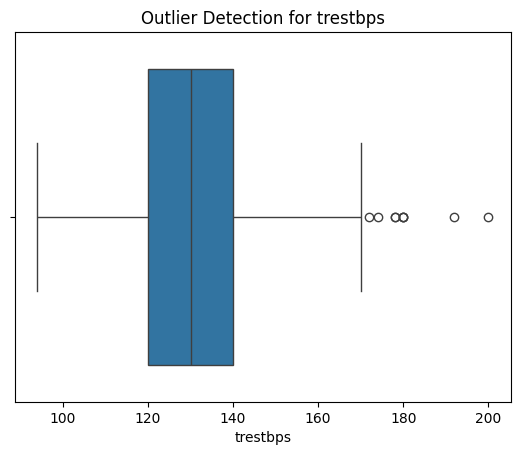

In [ ]:
# trestbps
sns.boxplot(df, x='trestbps')
plt.title('Outlier Detection for trestbps')
plt.show()

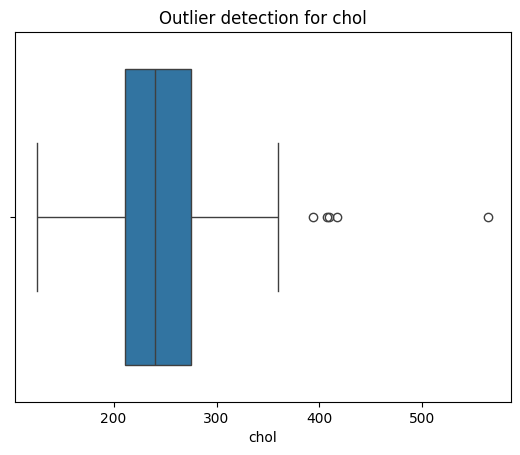

In [ ]:
# chol
sns.boxplot(df, x='chol')
plt.title('Outlier detection for chol')
plt.show()

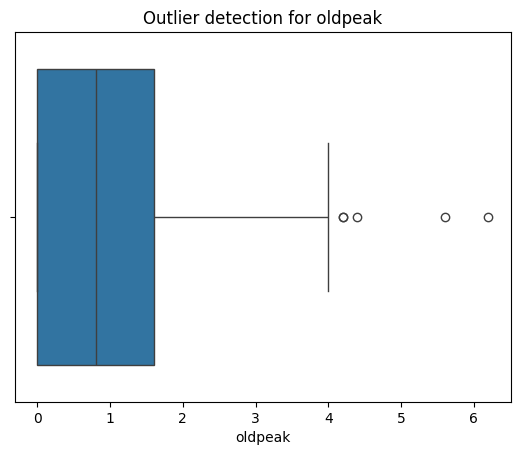

In [ ]:
# oldpeak
sns.boxplot(df, x='oldpeak')
plt.title('Outlier detection for oldpeak')
plt.show()

### **Observation**
* **Outlier analysi**s was performed using **Boxplots**.
* A **small no. of outliers** were identified in the variables **trestbps**, **chol**, and **oldpeak**.
* Since these values are medically plausible and may represent high-risk patients, they were retained to preserve important clinical information and **avoid loss of valuable patterns**.



## **Selecting the Target Variable.**
* According to the problem statement, **target** is the **target variable**.
* The **target** column was selected as the **dependent variable** because it represents the **presence or absence of heart disease**.
* target columns says
  * 0 - No Heart Disease
  * 1 - Heart Disease Present
* All remaining columns were used as predictor variables for model training.
* As the **target variable** is **available**, it is **Supervised** Machine learning Model.
* It means it can be either Regression or Classification depending upon the data type of the target variable.
* Since the target has only two possible values 0, 1 this is a **Binary Classification** Problem.

In [ ]:
# Let us select the target variable
# y = Output Variable / Dependent Variable / Target Variable
y = df['target']
y.shape

(302,)

In [ ]:
# Let us select input variable
# X = Input variable / Independent Variable / Predictors
X = df.drop(columns='target')
X.shape

(302, 13)

## **Splitting data into Train and Test Data.**
* For this we use **sklearn** library.
* Let us import train and test from sklearn.

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

* Let us verify the shape of train and test datasets.

In [ ]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(241, 13)
(61, 13)
(241,)
(61,)


### **Observations**
* The dataset was split into training and testing sets using an 80:20 ratio.
* The **training set (80%)** is used to train the machine learning models
* The **testing set (20%)** is used to evaluate model performance on unseen data.

## **Feature Scaling**

In [ ]:
from sklearn.preprocessing import StandardScaler
ss = StandardScaler()

X_train_trans = ss.fit_transform(X_train)
X_test_trans = ss.transform(X_test)

X_train_trans = pd.DataFrame(X_train_trans, columns=X_train.columns)
X_test_trans = pd.DataFrame(X_test_trans, columns=X_test.columns)

In [ ]:
X_train_trans.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,0.384770,0.672166,1.002575,0.437232,-0.666543,2.426049,-0.996893,0.673745,-0.665668,-0.863764,0.962408,-0.712101,-0.487904
1,-1.253560,0.672166,-0.953867,-1.017392,1.103135,-0.412193,0.940617,1.354552,-0.665668,0.150860,-0.670974,-0.712101,-0.487904
2,-0.598228,0.672166,1.002575,-0.842837,-1.859152,-0.412193,-0.996893,-0.985723,-0.665668,-0.187348,0.962408,2.213179,-0.487904
3,0.603213,0.672166,-0.953867,0.437232,0.910779,-0.412193,-0.996893,0.886497,-0.665668,0.150860,-0.670974,1.238085,1.122848
4,1.695433,0.672166,-0.953867,0.728157,-1.378261,-0.412193,0.940617,-1.028273,1.502251,1.334589,-2.304357,-0.712101,1.122848


In [ ]:
X_test_trans.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,-1.472004,0.672166,0.024354,-0.726467,-1.705267,-0.412193,0.940617,1.397103,-0.665668,-0.863764,0.962408,-0.712101,-0.487904
1,0.821657,-1.487728,-0.953867,0.437232,2.853578,-0.412193,-0.996893,0.333341,-0.665668,0.150860,-0.670974,-0.712101,-0.487904
2,-1.362782,0.672166,1.002575,-0.726467,-0.108709,2.426049,0.940617,1.907708,-0.665668,-0.187348,-2.304357,-0.712101,1.122848
3,-1.144338,0.672166,-0.953867,-0.726467,-1.474439,-0.412193,0.940617,-0.219815,1.502251,1.503693,-2.304357,-0.712101,-2.098657
4,-0.379784,0.672166,1.980796,-0.435542,-0.628071,-0.412193,-0.996893,-1.028273,1.502251,0.319965,0.962408,0.262992,-0.487904


<Axes: xlabel='thalach', ylabel='Density'>

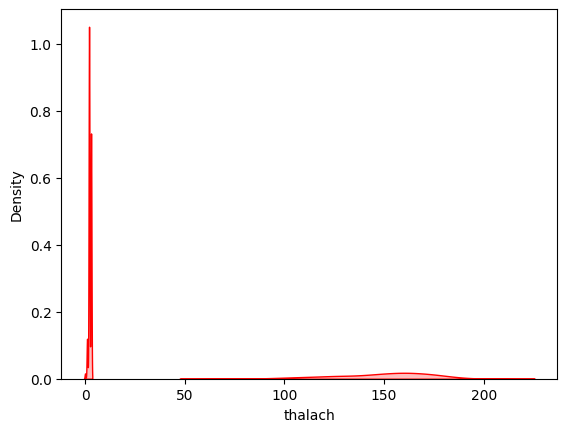

In [ ]:
sns.kdeplot(X_train, x='thalach', color='red', fill=True)
sns.kdeplot(X_train, x='thal', color='red', fill=True)


<Axes: xlabel='thalach', ylabel='Density'>

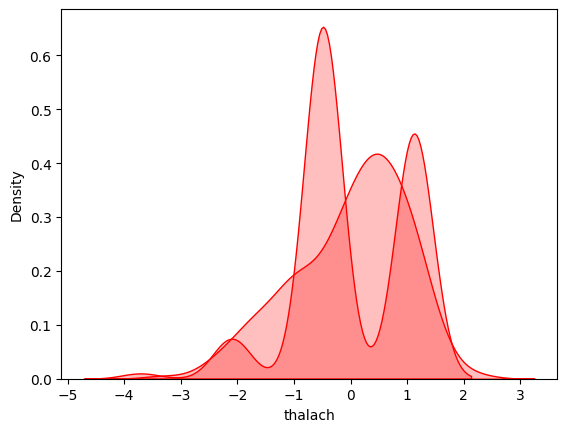

In [ ]:
sns.kdeplot(X_train_trans, x='thalach', color='red', fill=True)
sns.kdeplot(X_train_trans, x='thal', color='red', fill=True)


<Axes: xlabel='sex', ylabel='Density'>

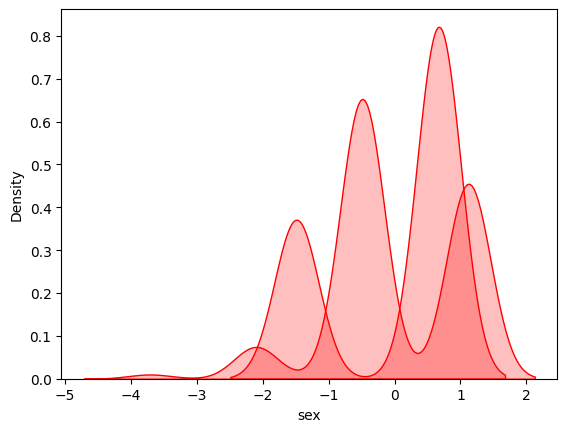

In [ ]:
sns.kdeplot(X_train_trans, x='sex', color='red', fill=True)
sns.kdeplot(X_train_trans, x='thal', color='red', fill=True)

## **Feature Selection**
### **Observation**
* Here, feature selection is not necessary.
* Feature selection is usually performed when:
  * There are too many features (50, 100, 1000+ columns)
  * Some columns are irrelevant (ID, Name, Address, Email, etc.)
  * Features are highly redundant
  * The model is overfitting
* But, All of them are:
  * Clinically meaningful
  * Commonly used in heart disease prediction
  * Not identifier columns

Therefore, there is no reason to remove features.

## **Model Selection**
#### **1. Logistic Regression**
**Why Selected?**

* It is one of the most **widely used algorithms** for **binary classification**.
* It **predicts the probability** of belonging to a class.

**Observation**

* Logistic Regression was chosen because it **performs well** when the relationship between features and the target is approximately **linear**.
* It also helps understand how individual medical factors influence heart disease prediction.

#### **2. K-Nearest Neighbors (KNN)**
**Why Selected?**
* KNN is a **distance-based algorithm**.
* It makes predictions based on similar patients in the dataset.
* It does not assume any underlying relationship between variables.

**Observation**

* KNN was selected to evaluate how well a similarity-based learning approach performs on the heart disease dataset.
* Since patients with similar medical characteristics may have similar outcomes, KNN provides an alternative prediction strategy compared to Logistic Regression.

#### **3. Random Forest**
**Why Selected?**

* Random Forest is an ensemble learning algorithm.
* It combines multiple decision trees.
* It captures complex and non-linear relationships.
* It is robust to noise and overfitting.

**Observation**

* Random Forest was selected because medical datasets often contain complex interactions among variables.
* The ensemble approach allows Random Forest to capture these patterns more effectively than individual models.

### **Why Not Other Models?**
**Decision Tree**

* Random Forest is an improved version of Decision Tree.
* It generally provides better accuracy and stability.

**Linear Regression**
* Linear Regression is designed for continuous numerical outputs.
* Your target variable is categorical (0 or 1).
* Therefore, Linear Regression is not suitable for this classification problem.

**SVM**
* SVM is a powerful classification algorithm.
* However, it requires more parameter tuning and computational effort.
* Logistic Regression, KNN, and Random Forest provide a good mix of simple, distance-based, and ensemble learning approaches.

## **Model Training**
### **Step-1: Baseline Evaluation Using Cross Validation**
### **1. Train Logistic Regression for Binary Classification**


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

lr = LogisticRegression(max_iter=1000)

lr_scores = cross_val_score(
    lr,
    X_train_trans,
    y_train,
    cv=5,
    scoring='recall'
)

print("Logistic Regression Recall Scores:")
print(lr_scores)
print("Average Recall:", lr_scores.mean())

Logistic Regression Recall Scores:
[0.76923077 0.88461538 0.92307692 0.92307692 0.92      ]
Average Recall: 0.884


## **2. Train KNN**

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier()

knn_scores = cross_val_score(
    knn,
    X_train_trans,
    y_train,
    cv=5,
    scoring='recall'
)

print("KNN Recall Scores:")
print(knn_scores)
print("Average Recall:", knn_scores.mean())

KNN Recall Scores:
[0.96153846 0.80769231 0.92307692 0.92307692 0.8       ]
Average Recall: 0.8830769230769231


## **3. Train Random Forest**

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)

rf_scores = cross_val_score(
    rf,
    X_train,
    y_train,
    cv=5,
    scoring='recall'
)

print("Random Forest Recall Scores:")
print(rf_scores)
print("Average Recall:", rf_scores.mean())

Random Forest Recall Scores:
[0.80769231 0.84615385 0.92307692 0.80769231 0.88      ]
Average Recall: 0.8529230769230768


## **Step-2: Hyperparameter Tuning**

### **Logistic Regression Tuning**

In [95]:
from sklearn.model_selection import GridSearchCV

lr_params = {
    'C':[0.01,0.1,1,10,100],
    'solver':['liblinear','lbfgs']
}

lr_grid = GridSearchCV(
    LogisticRegression(max_iter=1000),
    lr_params,
    cv=5,
    scoring='recall'
)

lr_grid.fit(X_train_trans,y_train)

print("Best Parameters:",lr_grid.best_params_)
print("Best Recall:",lr_grid.best_score_)

Best Parameters: {'C': 0.01, 'solver': 'lbfgs'}
Best Recall: 0.9298461538461538


### **KNN Tuning**

In [ ]:
knn_params = {
    'n_neighbors':[3,5,7,9,11],
    'weights':['uniform','distance']
}

knn_grid = GridSearchCV(
    KNeighborsClassifier(),
    knn_params,
    cv=5,
    scoring='recall'
)

knn_grid.fit(X_train_trans,y_train)

print("Best Parameters:",knn_grid.best_params_)
print("Best Recall:",knn_grid.best_score_)

Best Parameters: {'n_neighbors': 11, 'weights': 'uniform'}
Best Recall: 0.9221538461538461


### **Random Forest Tuning**

In [ ]:
rf_params = {
    'n_estimators':[100,200,300],
    'max_depth':[5,10,15,None],
    'min_samples_split':[2,5,10]
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    rf_params,
    cv=5,
    scoring='recall'
)

rf_grid.fit(X_train,y_train)

print("Best Parameters:",rf_grid.best_params_)
print("Best Recall:",rf_grid.best_score_)

Best Parameters: {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 100}
Best Recall: 0.8993846153846154


## **Step-3: Compare Tuned Models**

In [ ]:
results = pd.DataFrame({
    'Model':['Logistic Regression','KNN','Random Forest'],
    'Best Recall':[
        lr_grid.best_score_,
        knn_grid.best_score_,
        rf_grid.best_score_
    ]
})

results.sort_values(
    by='Best Recall',
    ascending=False
)

,Model,Best Recall
0,Logistic Regression,0.929846
1,KNN,0.922154
2,Random Forest,0.899385


## **Model Evaluation for all 3 models**

In [96]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'KNN', 'Random Forest'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_knn),
        accuracy_score(y_test, y_pred_rf)
    ],
    'Precision': [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_knn),
        precision_score(y_test, y_pred_rf)
    ],
    'Recall': [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_knn),
        recall_score(y_test, y_pred_rf)
    ],
    'F1 Score': [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_knn),
        f1_score(y_test, y_pred_rf)
    ]
})

results.sort_values(by='Recall', ascending=False)

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.803279,0.794872,0.885714,0.837838
2,Random Forest,0.786885,0.823529,0.800000,0.811594
1,KNN,0.737705,0.771429,0.771429,0.771429


### **Key Observations**
#### **Observation 1: Logistic Regression is the Best Overall Model**
After hyperparameter tuning:
* Highest Accuracy - 80.33%
* Highest Recall - 88.57%
* Highest F1 Score - 83.78%

This indicates that Logistic Regression provides the best balance between correctly identifying heart disease patients and minimizing misclassifications.

#### **Observation 2: Logistic Regression Has the Highest Recall**

* Recall = 88.57%

* Out of all patients who actually have heart disease, Logistic Regression correctly identifies about 89 out of every 100 patients.

* For healthcare applications, Recall is usually the most important metric because:

  * False Negative = Patient has heart disease
                 but model predicts healthy

  * Missing a patient is riskier than raising a false alarm.

#### **Observation 3: Random Forest Has the Highest Precision**

* Precision = 82.35%
* When Random Forest predicts heart disease, it is correct more often than the other models.
* However, it misses more actual heart disease cases than Logistic Regression (lower Recall).

#### **Observation 4: KNN Performed the Worst**
* Lowest Accuracy
* Lowest Recall
* Lowest F1 Score

This suggests that similarity-based classification is less effective for this dataset compared to Logistic Regression and Random Forest.

#### **Which Model is final?**
* **Select: Logistic Regression**

* Logistic Regression achieved:
  * Recall = 88.57%
  * Highest F1 Score
  * Highest Accuracy
* Therefore it is the clear winner.

### **Confusion Matrix for Logistic Regression**

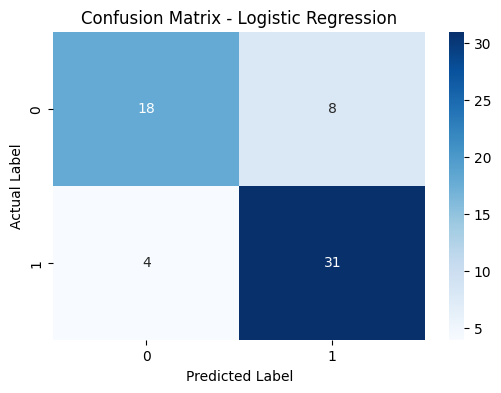

In [98]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6,4))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

### **Why Logistic Regression Performed Better**
* Logistic Regression achieved the highest Recall (88.57%), meaning it correctly identified most patients with heart disease.
* It also achieved the highest Accuracy (80.33%) and highest F1 Score (83.78%), indicating a strong balance between precision and recall.
* Since this is a healthcare problem, Recall was prioritized to minimize False Negatives (patients with heart disease incorrectly predicted as healthy).
* Cross-validation and hyperparameter tuning significantly improved Logistic Regression's performance compared to its baseline model.
* The model generalized well on unseen test data, demonstrating reliable predictive capability.